# Veridi Logistics — Last Mile Delivery Auditor
**Dataset:** Olist Brazilian E-Commerce  
**Objective:** Audit delivery performance, quantify delays, map geographic patterns, and correlate with customer sentiment.

---
## Setup
All CSV files should be placed in the `../data/` directory relative to this notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import json
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Fix Plotly rendering in VS Code notebooks
pio.renderers.default = 'notebook_connected'

# Consistent styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

---
## Story 1 — The Schema Builder
Join Orders + Reviews + Customers into a single master dataset without duplicating rows.

In [2]:
# ── Load raw CSVs (relative paths) ──────────────────────────────────────────
orders    = pd.read_csv('../data/olist_orders_dataset.csv')
reviews   = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
products  = pd.read_csv('../data/olist_products_dataset.csv')
items     = pd.read_csv('../data/olist_order_items_dataset.csv')
transl    = pd.read_csv('../data/product_category_name_translation.csv', encoding='utf-8-sig')  # BOM-safe

print(f'orders:    {orders.shape}')
print(f'reviews:   {reviews.shape}')
print(f'customers: {customers.shape}')
print(f'products:  {products.shape}')
print(f'items:     {items.shape}')
print(f'transl:    {transl.shape}')
print(f'\ntransl columns: {list(transl.columns)}')

orders:    (99441, 8)
reviews:   (99224, 7)
customers: (99441, 5)
products:  (32951, 9)
items:     (112650, 7)
transl:    (71, 2)

transl columns: ['product_category_name', 'product_category_name_english']


In [3]:
# ── Check cardinality: reviews per order ────────────────────────────────────
reviews_per_order = reviews.groupby('order_id')['review_id'].count()
print('Reviews per order (value counts):')
print(reviews_per_order.value_counts().head())

# Deduplicate: keep one review per order (earliest review_creation_date)
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews_dedup = (
    reviews.sort_values('review_creation_date')
           .drop_duplicates(subset='order_id', keep='first')
           [['order_id', 'review_score', 'review_creation_date']]
)
print(f'\nReviews after dedup: {reviews_dedup.shape[0]} rows (expected ≤ {orders.shape[0]})')

Reviews per order (value counts):
review_id
1    98126
2      543
3        4
Name: count, dtype: int64

Reviews after dedup: 98673 rows (expected ≤ 99441)


In [4]:
# ── Build master dataset ─────────────────────────────────────────────────────
master = (
    orders
    .merge(reviews_dedup[['order_id', 'review_score']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
)

# ── Row integrity check ──────────────────────────────────────────────────────
assert len(master) == len(orders), (
    f'Row count mismatch! master={len(master)}, orders={len(orders)}'
)
print(f'master shape: {master.shape}  ✓ No row duplication')
master.head(3)

master shape: (99441, 11)  ✓ No row duplication


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,GO,vianopolis


---
## Story 2 — The "Real" Delay Calculator
Create `delivery_delay_days` and classify each order as On Time / Late / Super Late.

In [5]:
# ── Parse datetime columns ───────────────────────────────────────────────────
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

# ── Exclude non-delivered orders ─────────────────────────────────────────────
excluded_statuses = ['canceled', 'unavailable']
excluded = master[master['order_status'].isin(excluded_statuses)].copy()
delivered = master[
    (~master['order_status'].isin(excluded_statuses)) &
    (master['order_delivered_customer_date'].notna())
].copy()

print(f'Total orders:          {len(master):,}')
print(f'Excluded (not delivered): {len(excluded):,}')
print(f'Delivered (for analysis): {len(delivered):,}')

Total orders:          99,441
Excluded (not delivered): 1,234
Delivered (for analysis): 96,470


In [6]:
# ── Calculate delay ──────────────────────────────────────────────────────────
# Positive = arrived LATER than estimated (bad)
# Negative = arrived EARLIER than estimated (good)
delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

# ── Classify ─────────────────────────────────────────────────────────────────
def classify_delivery(days):
    if days <= 0:
        return 'On Time'
    elif days <= 5:
        return 'Late'
    else:
        return 'Super Late'

delivered['delivery_status'] = delivered['delivery_delay_days'].apply(classify_delivery)

status_counts = delivered['delivery_status'].value_counts()
status_pct    = delivered['delivery_status'].value_counts(normalize=True) * 100

print('Delivery Status Summary:')
for s in ['On Time', 'Late', 'Super Late']:
    print(f'  {s:12s}: {status_counts[s]:>6,} orders  ({status_pct[s]:.1f}%)')

Delivery Status Summary:
  On Time     : 89,936 orders  (93.2%)
  Late        :  2,770 orders  (2.9%)
  Super Late  :  3,764 orders  (3.9%)


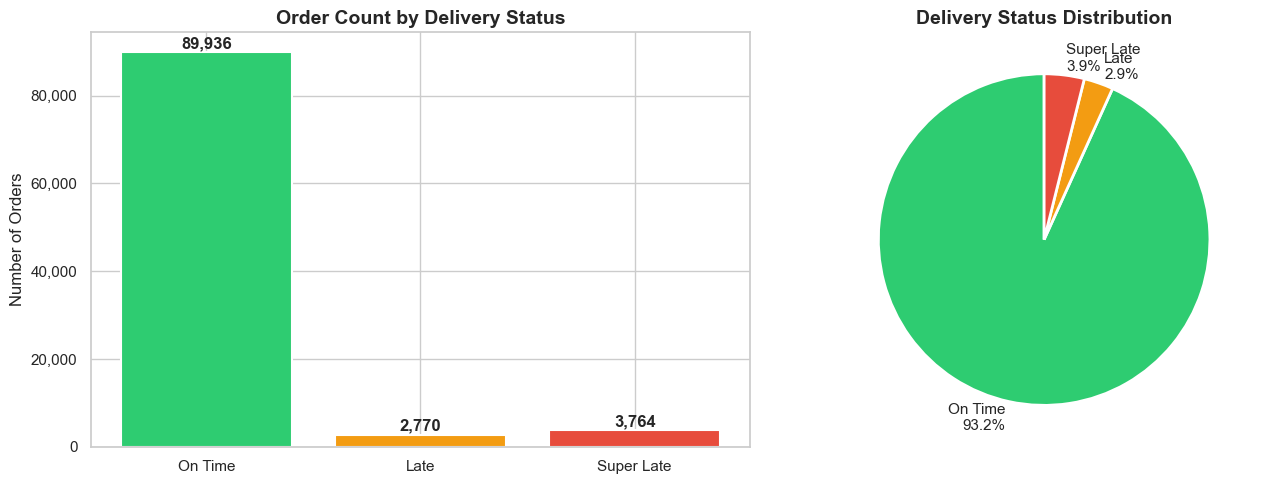

In [7]:
# ── Visualise: delivery status breakdown ─────────────────────────────────────
color_map = {'On Time': '#2ecc71', 'Late': '#f39c12', 'Super Late': '#e74c3c'}
order_cats = ['On Time', 'Late', 'Super Late']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
vals = [status_counts.get(s, 0) for s in order_cats]
bars = axes[0].bar(order_cats, vals, color=[color_map[s] for s in order_cats], edgecolor='white', linewidth=1.5)
axes[0].set_title('Order Count by Delivery Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
pcts = [status_pct.get(s, 0) for s in order_cats]
axes[1].pie(pcts, labels=[f'{s}\n{p:.1f}%' for s, p in zip(order_cats, pcts)],
            colors=[color_map[s] for s in order_cats],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Delivery Status Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../exports/fig_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Delay distribution histogram ─────────────────────────────────────────────
fig = px.histogram(
    delivered,
    x='delivery_delay_days',
    nbins=80,
    color='delivery_status',
    color_discrete_map=color_map,
    category_orders={'delivery_status': order_cats},
    title='Distribution of Delivery Delay (days)',
    labels={'delivery_delay_days': 'Days (negative = early, positive = late)', 'count': 'Orders'},
    opacity=0.85,
)
fig.add_vline(x=0, line_dash='dash', line_color='black', annotation_text='Estimated date')
fig.update_layout(bargap=0.05, legend_title='Status')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

---
## Story 3 — The Geographic Heatmap
Which Brazilian states have the highest rate of late deliveries?

In [ ]:
# ── Aggregate by state ───────────────────────────────────────────────────────
state_stats = (
    delivered
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('delivery_status', lambda x: (x != 'On Time').sum()),
        avg_delay=('delivery_delay_days', 'mean'),
        avg_review=('review_score', 'mean'),
    )
    .reset_index()
)
state_stats['pct_late'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(1)
state_stats['avg_delay'] = state_stats['avg_delay'].round(1)
state_stats['avg_review'] = state_stats['avg_review'].round(2)
state_stats = state_stats.sort_values('pct_late', ascending=False)

print('Top 10 states by % late deliveries:')
print(state_stats[['customer_state','total_orders','pct_late','avg_delay','avg_review']].head(10).to_string(index=False))

In [ ]:
# ── Bar chart: % late by state ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
palette = ['#e74c3c' if p > 20 else '#f39c12' if p > 10 else '#2ecc71'
           for p in state_stats['pct_late']]
bars = ax.barh(state_stats['customer_state'], state_stats['pct_late'],
               color=palette, edgecolor='white')
ax.set_xlabel('% Late Deliveries')
ax.set_title('Late Delivery Rate by Brazilian State', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Annotate each bar
for bar, val in zip(bars, state_stats['pct_late']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../exports/fig_state_late_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Choropleth map ────────────────────────────────────────────────────────────
# Fetch Brazil states GeoJSON
geojson_url = (
    'https://raw.githubusercontent.com/codeforamerica/click_that_hood/'
    'master/public/data/brazil-states.geojson'
)
with urllib.request.urlopen(geojson_url) as response:
    brazil_geo = json.load(response)

# Standardize the property key used for matching
for feature in brazil_geo['features']:
    feature['id'] = feature['properties'].get('sigla', feature['properties'].get('uf', ''))

fig = px.choropleth(
    state_stats,
    geojson=brazil_geo,
    locations='customer_state',
    color='pct_late',
    color_continuous_scale='RdYlGn_r',
    range_color=(0, state_stats['pct_late'].max()),
    hover_data={'total_orders': True, 'avg_delay': True, 'avg_review': True},
    title='Late Delivery Rate (%) by Brazilian State',
    labels={'pct_late': '% Late', 'customer_state': 'State'},
    fitbounds='locations',
    basemap_visible=False,
)
fig.update_layout(margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig.show()

In [ ]:
# ── Insight: Remote vs. Core states ─────────────────────────────────────────
remote_states = ['AM', 'RR', 'AC', 'AP', 'RO', 'PA', 'TO', 'MA']
core_states   = ['SP', 'RJ', 'MG', 'PR', 'RS', 'SC']

remote_pct = state_stats[state_stats['customer_state'].isin(remote_states)]['pct_late'].mean()
core_pct   = state_stats[state_stats['customer_state'].isin(core_states)]['pct_late'].mean()

print(f'Average late rate — Remote/Northern states: {remote_pct:.1f}%')
print(f'Average late rate — Core/Southern states:   {core_pct:.1f}%')
print(f'Remote states are {remote_pct/core_pct:.1f}x more likely to receive a late delivery.')

---
## Story 4 — The Sentiment Correlation
Do late deliveries actually cause bad reviews?

In [ ]:
# ── Average review score by delivery status ──────────────────────────────────
sentiment = (
    delivered.dropna(subset=['review_score'])
    .groupby('delivery_status')['review_score']
    .agg(['mean', 'median', 'count'])
    .reindex(order_cats)
    .reset_index()
)
sentiment.columns = ['delivery_status', 'avg_score', 'median_score', 'n_orders']
print(sentiment.to_string(index=False))

In [ ]:
# ── Bar chart: avg review score by status ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    sentiment['delivery_status'],
    sentiment['avg_score'],
    color=[color_map[s] for s in sentiment['delivery_status']],
    edgecolor='white', linewidth=1.5
)
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel('Average Review Score (1–5)')
axes[0].set_title('Average Review Score by Delivery Status', fontsize=13, fontweight='bold')
axes[0].axhline(y=delivered['review_score'].mean(), color='grey', linestyle='--', label='Overall avg')
axes[0].legend()
for bar, val in zip(bars, sentiment['avg_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)

# ── Box plot: review score distribution by status ────────────────────────────
plot_data = delivered.dropna(subset=['review_score'])
groups = [plot_data[plot_data['delivery_status'] == s]['review_score'].values
          for s in order_cats]
bp = axes[1].boxplot(groups, labels=order_cats, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp['boxes'], order_cats):
    patch.set_facecolor(color_map[s])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Review Score')
axes[1].set_title('Review Score Distribution by Delivery Status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../exports/fig_sentiment_by_status.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Scatter: delay days vs review score (binned for clarity) ─────────────────
# Bin delay into 2-day buckets and compute mean review score per bin
delivered['delay_bin'] = pd.cut(
    delivered['delivery_delay_days'],
    bins=range(-30, 80, 2),
    labels=False
)
bin_summary = (
    delivered.dropna(subset=['review_score', 'delay_bin'])
    .groupby('delay_bin')
    .agg(avg_review=('review_score', 'mean'), count=('order_id', 'count'))
    .reset_index()
)
bin_summary['delay_midpoint'] = bin_summary['delay_bin'] * 2 - 30 + 1

fig = px.scatter(
    bin_summary,
    x='delay_midpoint',
    y='avg_review',
    size='count',
    color='avg_review',
    color_continuous_scale='RdYlGn',
    range_color=[1, 5],
    title='Average Review Score vs Delivery Delay (binned, bubble = order volume)',
    labels={'delay_midpoint': 'Delay (days, negative = early)', 'avg_review': 'Avg Review Score'},
    trendline='lowess',
)
fig.add_vline(x=0, line_dash='dash', line_color='black', annotation_text='On time')
fig.update_layout(coloraxis_showscale=False)
fig.show()

In [ ]:
# ── Review score % breakdown by status ──────────────────────────────────────
score_dist = (
    delivered.dropna(subset=['review_score'])
    .groupby(['delivery_status', 'review_score'])
    .size()
    .reset_index(name='count')
)
score_dist['review_score'] = score_dist['review_score'].astype(str)

fig = px.bar(
    score_dist,
    x='delivery_status',
    y='count',
    color='review_score',
    barmode='stack',
    color_discrete_sequence=px.colors.sequential.RdYlGn,
    title='Review Score Distribution by Delivery Status',
    labels={'count': 'Number of Orders', 'delivery_status': 'Status', 'review_score': 'Score'},
    category_orders={'delivery_status': order_cats},
)
fig.show()

---
## Bonus — Product Category Translation
Translate Portuguese category names to English and see which categories have the most late deliveries.

In [ ]:
# ── Join: items → products → translation → orders ────────────────────────────
products_en = products.merge(
    transl[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)
# One item per order (take first item's category if multiple)
items_primary = (
    items[['order_id', 'product_id']]
    .drop_duplicates(subset='order_id', keep='first')
)
items_cat = items_primary.merge(
    products_en[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)
delivered_cat = delivered.merge(items_cat, on='order_id', how='left')
delivered_cat['product_category_name_english'] = (
    delivered_cat['product_category_name_english']
    .fillna('unknown')
    .str.replace('_', ' ')
    .str.title()
)
print(f'Categories attached: {delivered_cat["product_category_name_english"].notna().sum():,} orders')

In [ ]:
# ── Category-level late rate ──────────────────────────────────────────────────
cat_stats = (
    delivered_cat[delivered_cat['product_category_name_english'] != 'Unknown']
    .groupby('product_category_name_english')
    .agg(
        total=('order_id', 'count'),
        late=('delivery_status', lambda x: (x != 'On Time').sum()),
        avg_review=('review_score', 'mean'),
    )
    .reset_index()
)
cat_stats['pct_late'] = (cat_stats['late'] / cat_stats['total'] * 100).round(1)
cat_stats = cat_stats[cat_stats['total'] >= 50]  # minimum volume filter
top20_cat = cat_stats.nlargest(20, 'pct_late')

fig = px.bar(
    top20_cat.sort_values('pct_late'),
    x='pct_late',
    y='product_category_name_english',
    orientation='h',
    color='avg_review',
    color_continuous_scale='RdYlGn',
    range_color=[1, 5],
    title='Top 20 Categories by Late Delivery Rate (min 50 orders)',
    labels={'pct_late': '% Late Deliveries', 'product_category_name_english': 'Category',
            'avg_review': 'Avg Review'},
    text_auto='.1f',
)
fig.update_traces(texttemplate='%{x:.1f}%', textposition='outside')
fig.update_layout(height=600)
fig.show()

---
## Candidate's Choice — Pipeline Breakdown
**"Where does the delay actually happen — warehouse or transit?"**

> **Business value:** Knowing a delivery is late is not actionable. Knowing whether the bottleneck is inside the warehouse (fixable via ops) or in transit (fixable via carrier SLA renegotiation) turns this audit into a roadmap.

In [ ]:
# ── Calculate three pipeline phases (only for rows with all timestamps) ──────
pipeline = delivered.dropna(subset=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
]).copy()

pipeline['processing_days'] = (
    pipeline['order_approved_at'] - pipeline['order_purchase_timestamp']
).dt.total_seconds() / 86400

pipeline['warehouse_days'] = (
    pipeline['order_delivered_carrier_date'] - pipeline['order_approved_at']
).dt.total_seconds() / 86400

pipeline['transit_days'] = (
    pipeline['order_delivered_customer_date'] - pipeline['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Remove implausible negative durations
for col in ['processing_days', 'warehouse_days', 'transit_days']:
    pipeline = pipeline[pipeline[col] >= 0]

phase_by_status = (
    pipeline.groupby('delivery_status')[['processing_days', 'warehouse_days', 'transit_days']]
    .mean()
    .reindex(order_cats)
    .round(1)
)
print('Average pipeline phase durations (days) by delivery status:')
print(phase_by_status)

In [ ]:
# ── Stacked bar: phase breakdown by status ────────────────────────────────────
phase_plot = phase_by_status.reset_index().melt(
    id_vars='delivery_status', var_name='Phase', value_name='Days'
)
phase_labels = {
    'processing_days': 'Payment Processing',
    'warehouse_days': 'Warehouse → Carrier',
    'transit_days': 'Carrier → Customer'
}
phase_plot['Phase'] = phase_plot['Phase'].map(phase_labels)

fig = px.bar(
    phase_plot,
    x='delivery_status',
    y='Days',
    color='Phase',
    barmode='stack',
    color_discrete_sequence=['#3498db', '#9b59b6', '#e67e22'],
    title='Where Does the Time Go? — Average Pipeline Phases by Delivery Status',
    labels={'delivery_status': 'Delivery Status', 'Days': 'Average Days'},
    category_orders={'delivery_status': order_cats},
    text_auto='.1f',
)
fig.update_traces(textposition='inside', insidetextanchor='middle')
fig.update_layout(legend_title='Pipeline Phase')
fig.show()

In [ ]:
# ── Key insight text ──────────────────────────────────────────────────────────
ontime_transit  = phase_by_status.loc['On Time', 'transit_days']
late_transit    = phase_by_status.loc['Late', 'transit_days']
slat_transit    = phase_by_status.loc['Super Late', 'transit_days']

ontime_wh  = phase_by_status.loc['On Time', 'warehouse_days']
slat_wh    = phase_by_status.loc['Super Late', 'warehouse_days']

print('Pipeline Insight:')
print(f'  Transit days  — On Time: {ontime_transit:.1f}  |  Late: {late_transit:.1f}  |  Super Late: {slat_transit:.1f}')
print(f'  Warehouse days — On Time: {ontime_wh:.1f}  |  Super Late: {slat_wh:.1f}')
dominant = 'TRANSIT' if (slat_transit - ontime_transit) > (slat_wh - ontime_wh) else 'WAREHOUSE'
print(f'\n>>> Primary delay driver: {dominant} phase')
print('>>> Recommended action:', (
    'Negotiate carrier SLAs or switch logistics provider for remote routes.'
    if dominant == 'TRANSIT' else
    'Audit internal order fulfilment processes — reduce warehouse dwell time.'
))

---
## Save processed data for Dashboard

In [ ]:
# Save enriched delivered DataFrame so the Streamlit dashboard can load it quickly
dashboard_cols = [
    'order_id', 'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'customer_state', 'customer_city',
    'delivery_delay_days', 'delivery_status', 'review_score',
]
delivered[dashboard_cols].to_parquet('../data/processed_master.parquet', index=False)

state_stats.to_parquet('../data/state_stats.parquet', index=False)

# Save category data
cat_dashboard_cols = dashboard_cols + ['product_category_name_english']
delivered_cat[cat_dashboard_cols].to_parquet('../data/processed_master_cat.parquet', index=False)

# Save pipeline phase data
pipeline_cols = dashboard_cols + ['processing_days', 'warehouse_days', 'transit_days']
pipeline[pipeline_cols].to_parquet('../data/pipeline.parquet', index=False)

print('Processed data saved to ../data/')